# Heart Failure Prediction using Support Vector Machine (SVM) and SMOTE

This notebook builds a heart failure prediction model using the `heart.csv` dataset. It utilizes SMOTE to balance the dataset and trains a Support Vector Machine (SVM) classifier.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Load Data and Check Original Class Distribution

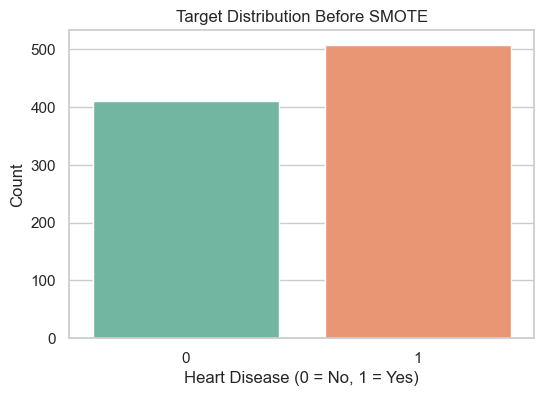

In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Display the original class distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    x='HeartDisease',
    data=df,
    hue='HeartDisease',
    palette='Set2',
    legend=False
)
plt.title('Target Distribution Before SMOTE')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 2. Data Preprocessing
We need to encode categorical variables into numeric values so the model can process them. Since SVM is sensitive to feature scale, we also standardize the data after splitting and applying SMOTE.

In [3]:
# Identify categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Apply SMOTE to Balance the Training Data

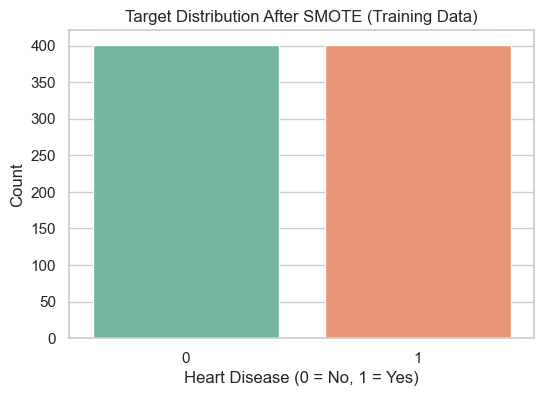

In [4]:
# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display the class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette='Set2',
    legend=False
)
plt.title('Target Distribution After SMOTE (Training Data)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 4. Train Support Vector Machine (SVM) Model
Training the model using the `rbf` kernel after scaling the features.

In [5]:
# Initialize the scaler
scaler = StandardScaler()

# Scale the balanced training data and the test data
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Initialize Support Vector Machine
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model on the balanced and scaled data
svm_model.fit(X_train_smote_scaled, y_train_smote)

# Make predictions on the scaled test set
y_pred = svm_model.predict(X_test_scaled)

### 5. Evaluation and Visualizations

In [6]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy as a decimal
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.8696

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85        77
           1       0.90      0.87      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



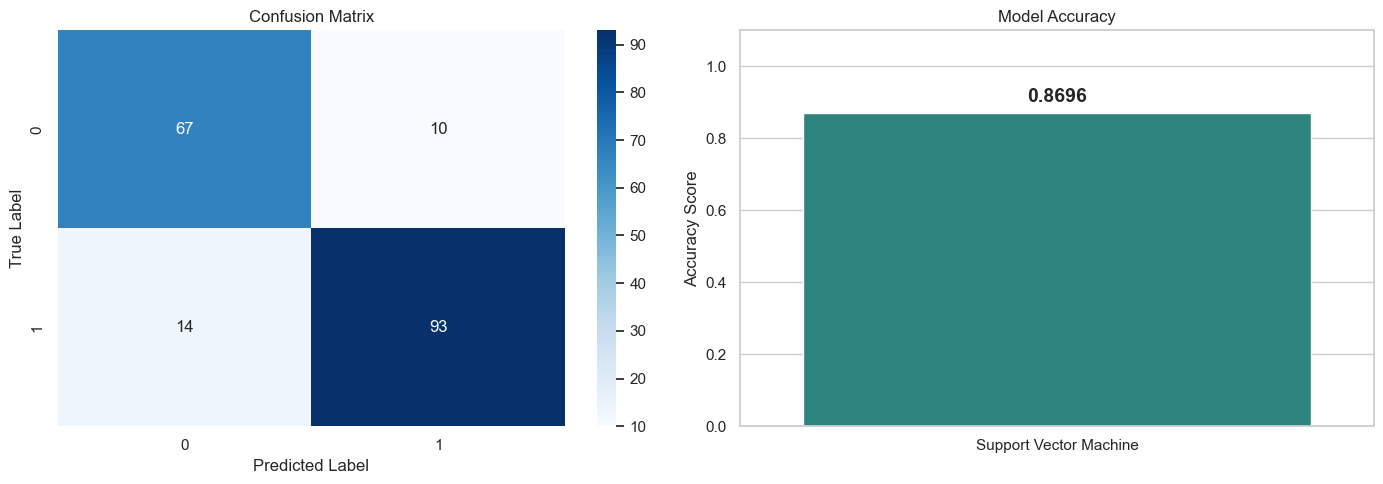

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Graph
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# 2. Accuracy Graph (FIXED)
sns.barplot(
    x=['Support Vector Machine'],
    y=[accuracy],
    hue=['Support Vector Machine'],   # added
    palette='viridis',
    ax=ax[1],
    legend=False
)

ax[1].set_ylim(0, 1.1)
ax[1].set_title('Model Accuracy')
ax[1].set_ylabel('Accuracy Score')

# Add accuracy value on top
ax[1].text(
    0,
    accuracy + 0.02,
    f"{accuracy:.4f}",
    ha='center',
    va='bottom',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()